In [6]:
# بحث باستخدام أوامر Linux
!find / -name "medquad.csv" 2>/dev/null | head -10

/content/medquad.csv


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


📚 درس Tokenization - تقطيع النصوص العربية

📊 عدد النصوص: 10

📝 النصوص العربية:
1. المنتج رائع جداً وأنا سعيد بشرائه
2. الخدمة سيئة ولا أنصح بالتعامل معهم
3. الفيلم كان ممتاز واستمتعت بمشاهدته كثيراً
4. الطعام لذيذ والمكان نظيف ومرتب
5. التجربة كانت محبطة ولن أكررها مرة أخرى
6. الجودة ممتازة وسأشتري مرة أخرى بالتأكيد
7. الموظفون غير محترفين والخدمة بطيئة
8. الله كريم والحمدلله على كل حال
9. الدنيا قاسية ولكن يجب أن نتفاءل
10. هذا أفضل منتج استخدمته في حياتي

1️⃣ Tokenization أساسي (بتقسيم المسافات)

النص الأصلي: المنتج رائع جداً وأنا سعيد بشرائه
الطول: 33 حرف
بعد التقطيع: ['المنتج', 'رائع', 'جداً', 'وأنا', 'سعيد', 'بشرائه']
عدد الكلمات: 6

2️⃣ Tokenization باستخدام NLTK (أكثر دقة)
نتائج التقطيع لكل نص:
--------------------------------------------------

نص 1: المنتج رائع جداً وأنا سعيد بشر...
   الكلمات: ['المنتج', 'رائع', 'جداً', 'وأنا', 'سعيد', 'بشرائه']
   العدد: 6

نص 2: الخدمة سيئة ولا أنصح بالتعامل ...
   الكلمات: ['الخدمة', 'سيئة', 'ولا', 'أنصح', 'بالتعامل', 'معهم']
   العدد: 6



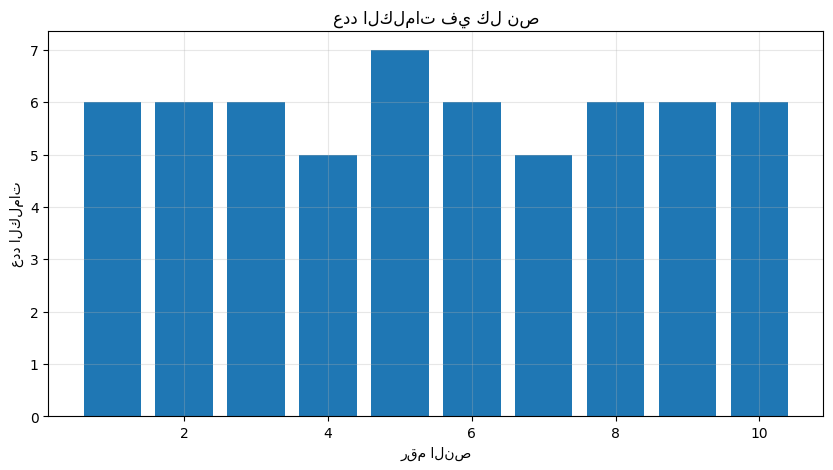


9️⃣ حفظ النتائج
✅ تم حفظ النتائج في 'tokenization_results.csv'

📚 خلاصة درس Tokenization

ما تعلمناه:
1️⃣ التقطيع البسيط: text.split()
2️⃣ التقطيع المتقدم: word_tokenize()
3️⃣ تنظيف النصوص قبل التقطيع
4️⃣ إحصائيات وتحليل الكلمات
5️⃣ تطبيقات عملية

💡 معلومة مهمة:
التقطيع هو أول خطوة في أي مشروع NLP!



In [1]:
# ===========================================
# الدرس 1: Tokenization (تقطيع النص)
# ===========================================

# تثبيت المكتبات المطلوبة
!pip install nltk arabic-reshaper python-bidi -q

import nltk
import re
import pandas as pd
from nltk.tokenize import word_tokenize, sent_tokenize
import matplotlib.pyplot as plt
from collections import Counter

import nltk
nltk.download('punkt_tab')  # هذا السطر يحل المشكلة
# ثم استخدم بعدها
from nltk.tokenize import word_tokenize

# تحميل بيانات NLTK
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

print("="*70)
print("📚 درس Tokenization - تقطيع النصوص العربية")
print("="*70)

# -------------------------------------------------------------------------
# 1. بيانات عربية للتدريب
# -------------------------------------------------------------------------
arabic_texts = [
    "المنتج رائع جداً وأنا سعيد بشرائه",
    "الخدمة سيئة ولا أنصح بالتعامل معهم",
    "الفيلم كان ممتاز واستمتعت بمشاهدته كثيراً",
    "الطعام لذيذ والمكان نظيف ومرتب",
    "التجربة كانت محبطة ولن أكررها مرة أخرى",
    "الجودة ممتازة وسأشتري مرة أخرى بالتأكيد",
    "الموظفون غير محترفين والخدمة بطيئة",
    "الله كريم والحمدلله على كل حال",
    "الدنيا قاسية ولكن يجب أن نتفاءل",
    "هذا أفضل منتج استخدمته في حياتي"
]

print(f"\n📊 عدد النصوص: {len(arabic_texts)}")
print("\n📝 النصوص العربية:")
for i, text in enumerate(arabic_texts, 1):
    print(f"{i}. {text}")

# -------------------------------------------------------------------------
# 2. Tokenization أساسي (بالمسافات)
# -------------------------------------------------------------------------
print("\n" + "="*70)
print("1️⃣ Tokenization أساسي (بتقسيم المسافات)")
print("="*70)

def basic_tokenization(text):
    """تقطيع بسيط باستخدام المسافات"""
    return text.split()

# تجربة على أول نص
first_text = arabic_texts[0]
tokens_basic = basic_tokenization(first_text)

print(f"\nالنص الأصلي: {first_text}")
print(f"الطول: {len(first_text)} حرف")
print(f"بعد التقطيع: {tokens_basic}")
print(f"عدد الكلمات: {len(tokens_basic)}")

# -------------------------------------------------------------------------
# 3. Tokenization باستخدام NLTK
# -------------------------------------------------------------------------
print("\n" + "="*70)
print("2️⃣ Tokenization باستخدام NLTK (أكثر دقة)")
print("="*70)

# تجربة على جميع النصوص
all_tokens = []
print("نتائج التقطيع لكل نص:")
print("-"*50)

for i, text in enumerate(arabic_texts, 1):
    tokens = word_tokenize(text)
    all_tokens.extend(tokens)
    print(f"\nنص {i}: {text[:30]}...")
    print(f"   الكلمات: {tokens}")
    print(f"   العدد: {len(tokens)}")

# -------------------------------------------------------------------------
# 4. إزالة علامات الترقيم
# -------------------------------------------------------------------------
print("\n" + "="*70)
print("3️⃣ تنظيف النصوص قبل التقطيع")
print("="*70)

def clean_and_tokenize(text):
    """تنظيف النص ثم تقطيعه"""
    # إزالة علامات الترقيم
    text = re.sub(r'[^\w\s]', '', text)
    # تقطيع
    tokens = word_tokenize(text)
    return tokens

# تجربة
text_with_punct = "المنتج: رائع! جداً؟ وأنا سعيد..."
cleaned_tokens = clean_and_tokenize(text_with_punct)

print(f"النص الأصلي: {text_with_punct}")
print(f"بعد التنظيف والتقطيع: {cleaned_tokens}")

# -------------------------------------------------------------------------
# 5. إحصائيات التقطيع
# -------------------------------------------------------------------------
print("\n" + "="*70)
print("4️⃣ إحصائيات التقطيع")
print("="*70)

# حساب إحصائيات جميع النصوص
all_lengths = []
all_words = []

for text in arabic_texts:
    tokens = word_tokenize(text)
    all_lengths.append(len(tokens))
    all_words.extend(tokens)

print(f"📊 إحصائيات عامة:")
print(f"   إجمالي النصوص: {len(arabic_texts)}")
print(f"   إجمالي الكلمات: {len(all_words)}")
print(f"   متوسط الكلمات لكل نص: {sum(all_lengths)/len(all_lengths):.1f}")
print(f"   أقل عدد كلمات: {min(all_lengths)}")
print(f"   أكثر عدد كلمات: {max(all_lengths)}")

# -------------------------------------------------------------------------
# 6. الكلمات الأكثر تكراراً
# -------------------------------------------------------------------------
print("\n" + "="*70)
print("5️⃣ الكلمات الأكثر تكراراً")
print("="*70)

word_freq = Counter(all_words)
print("أكثر 10 كلمات تكراراً:")
for word, count in word_freq.most_common(10):
    print(f"   • '{word}': {count} مرة")

# -------------------------------------------------------------------------
# 7. أنواع التقطيع المختلفة
# -------------------------------------------------------------------------
print("\n" + "="*70)
print("6️⃣ أنواع التقطيع المختلفة")
print("="*70)

text = "السلام عليكم ورحمة الله وبركاته"

# تقطيع إلى كلمات
words = word_tokenize(text)
print(f"تقطيع كلمات: {words}")

# تقطيع إلى جمل
sentences = sent_tokenize(text + " كيف حالك؟ أنا بخير")
print(f"تقطيع جمل: {sentences}")

# تقطيع بالحروف
chars = list(text)
print(f"تقطيع أحرف: {chars[:10]}...")

# -------------------------------------------------------------------------
# 8. تطبيق عملي - تحضير بيانات للتدريب
# -------------------------------------------------------------------------
print("\n" + "="*70)
print("7️⃣ تطبيق عملي - تحضير بيانات للتدريب")
print("="*70)

# تجهيز بيانات للتدريب
training_data = []
for text in arabic_texts:
    # تنظيف وتقطيع
    tokens = clean_and_tokenize(text)
    training_data.append({
        'النص_الأصلي': text,
        'عدد_الكلمات': len(tokens),
        'الكلمات': tokens,
        'أول_3_كلمات': tokens[:3] if len(tokens) >= 3 else tokens
    })

# عرض كـ DataFrame
df = pd.DataFrame(training_data)
print(df[['النص_الأصلي', 'عدد_الكلمات', 'أول_3_كلمات']].to_string())

# -------------------------------------------------------------------------
# 9. رسم بياني لعدد الكلمات
# -------------------------------------------------------------------------
print("\n" + "="*70)
print("8️⃣ رسم بياني - توزيع عدد الكلمات")
print("="*70)

plt.figure(figsize=(10, 5))
plt.bar(range(1, len(all_lengths)+1), all_lengths)
plt.xlabel('رقم النص')
plt.ylabel('عدد الكلمات')
plt.title('عدد الكلمات في كل نص')
plt.grid(True, alpha=0.3)
plt.show()

# -------------------------------------------------------------------------
# 10. حفظ النتائج
# -------------------------------------------------------------------------
print("\n" + "="*70)
print("9️⃣ حفظ النتائج")
print("="*70)

# حفظ كملف CSV
df.to_csv('tokenization_results.csv', index=False, encoding='utf-8')
print("✅ تم حفظ النتائج في 'tokenization_results.csv'")

# -------------------------------------------------------------------------
# خلاصة الدرس
# -------------------------------------------------------------------------
print("\n" + "="*70)
print("📚 خلاصة درس Tokenization")
print("="*70)
print("""
ما تعلمناه:
1️⃣ التقطيع البسيط: text.split()
2️⃣ التقطيع المتقدم: word_tokenize()
3️⃣ تنظيف النصوص قبل التقطيع
4️⃣ إحصائيات وتحليل الكلمات
5️⃣ تطبيقات عملية

💡 معلومة مهمة:
التقطيع هو أول خطوة في أي مشروع NLP!
""")

ERROR: Ignored the following versions that require a different python version: 1.5.0 Requires-Python >=3.7.0, <3.11; 1.5.1 Requires-Python >=3.7.0, <3.11; 1.5.2 Requires-Python >=3.7.0, <3.11; 1.5.3 Requires-Python <3.12,>=3.8.0; 1.5.4 Requires-Python <3.12,>=3.8.0
ERROR: Could not find a version that satisfies the requirement farasa-py (from versions: none)
ERROR: No matching distribution found for farasa-py

📊 عدد الجمل: 10

📝 الجمل العربية:
1. الولد يأكل التفاحة
2. الفتاة الجميلة تقرأ كتاباً مفيداً
3. السيارة الحمراء تسير بسرعة
4. المعلم يشرح الدرس للطلاب
5. السماء صافية والجو جميل
6. محمد يلعب كرة القدم مع أصدقائه
7. القطة تنام على الكرسي المريح
8. أكلت التفاحة الحمراء اللذيذة
9. الرجل العجوز يمشي ببطء
10. الأطفال يلعبون في الحديقة

📝 الجملة: الولد يأكل التفاحة
   التقطيع: ['الولد', 'يأكل', 'التفاحة']

📝 الجملة: الفتاة الجميلة تقرأ كتاباً مفيداً
   التقطيع: ['الفتاة', 'الجميلة', 'تقرأ', 'كتاباً', 'مفيداً']

📝 الجملة: السيارة الحمراء تسير بسرعة
   التقطيع: ['السيارة', 'الحمراء', 'تس

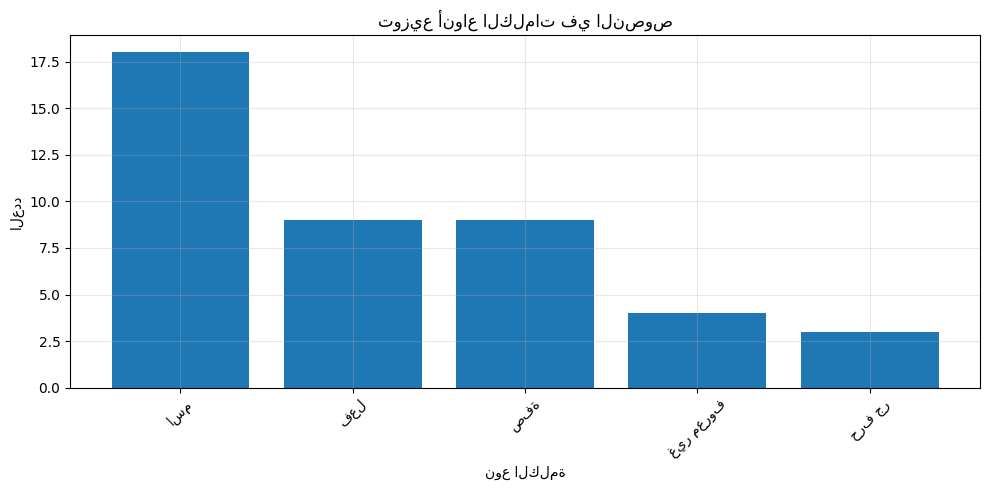

 الجملة  الكلمة     النوع                    الجملة_الكاملة
      1   الولد       اسم                الولد يأكل التفاحة
      1    يأكل       فعل                الولد يأكل التفاحة
      1 التفاحة       اسم                الولد يأكل التفاحة
      2  الفتاة       اسم الفتاة الجميلة تقرأ كتاباً مفيداً
      2 الجميلة       صفة الفتاة الجميلة تقرأ كتاباً مفيداً
      2    تقرأ       فعل الفتاة الجميلة تقرأ كتاباً مفيداً
      2  كتاباً       اسم الفتاة الجميلة تقرأ كتاباً مفيداً
      2  مفيداً       صفة الفتاة الجميلة تقرأ كتاباً مفيداً
      3 السيارة       اسم        السيارة الحمراء تسير بسرعة
      3 الحمراء       صفة        السيارة الحمراء تسير بسرعة
      3    تسير       فعل        السيارة الحمراء تسير بسرعة
      3   بسرعة غير معروف        السيارة الحمراء تسير بسرعة
      4  المعلم       اسم          المعلم يشرح الدرس للطلاب
      4    يشرح       فعل          المعلم يشرح الدرس للطلاب
      4   الدرس       اسم          المعلم يشرح الدرس للطلاب
      4  للطلاب غير معروف          المعل

In [8]:
# ===========================================
# الدرس: POS Tagging - وسم أجزاء الكلام
# ===========================================

# تثبيت المكتبات المطلوبة
!pip install nltk camel-tools farasa-py -q

import nltk
import re
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# تحميل بيانات NLTK
nltk.download('punkt_tab', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('universal_tagset', quiet=True)


# -------------------------------------------------------------------------
# 1️⃣ بيانات عربية للتدريب
# -------------------------------------------------------------------------
arabic_sentences = [
    "الولد يأكل التفاحة",
    "الفتاة الجميلة تقرأ كتاباً مفيداً",
    "السيارة الحمراء تسير بسرعة",
    "المعلم يشرح الدرس للطلاب",
    "السماء صافية والجو جميل",
    "محمد يلعب كرة القدم مع أصدقائه",
    "القطة تنام على الكرسي المريح",
    "أكلت التفاحة الحمراء اللذيذة",
    "الرجل العجوز يمشي ببطء",
    "الأطفال يلعبون في الحديقة"
]

print(f"\n📊 عدد الجمل: {len(arabic_sentences)}")
print("\n📝 الجمل العربية:")
for i, sent in enumerate(arabic_sentences, 1):
    print(f"{i}. {sent}")

# -------------------------------------------------------------------------
# 2️⃣ التقطيع أولاً

from nltk.tokenize import word_tokenize

tokens_list = []
for sent in arabic_sentences:
    tokens = word_tokenize(sent)
    tokens_list.append(tokens)
    print(f"\n📝 الجملة: {sent}")
    print(f"   التقطيع: {tokens}")

# -------------------------------------------------------------------------
# 3️⃣ POS Tagging باستخدام NLTK (للغة الإنجليزية - شرح المبدأ)
# -------------------------------------------------------------------------

# جملة إنجليزية للشرح
eng_sentence = "The boy eats an apple"
eng_tokens = word_tokenize(eng_sentence)
eng_pos = nltk.pos_tag(eng_tokens)

print(f"\nالجملة: {eng_sentence}")
print(f"التقطيع: {eng_tokens}")
print(f"POS Tags: {eng_pos}")

print("\n📌 شرح الرموز:")
print("   DT → Determiner (أداة تعريف)")
print("   NN → Noun (اسم)")
print("   VBZ → Verb (فعل)")
print("   IN → Preposition (حرف جر)")

# -------------------------------------------------------------------------
# 4️⃣ استخدام Camel-Tools (للعربية)
# -------------------------------------------------------------------------

try:
    import camel_tools
    from camel_tools.tokenizers.word import simple_word_tokenize
    from camel_tools.disambig.mle import MLEDisambiguator
    from camel_tools.tagger.default import DefaultTagger

    print("✅ تم تحميل Camel-Tools")

    # تحميل النموذج
    mle = MLEDisambiguator.pretrained()
    tagger = DefaultTagger(mle, 'pos')

    # تطبيق على بعض الجمل
    for i, sent in enumerate(arabic_sentences[:3], 1):
        # تقطيع
        tokens = simple_word_tokenize(sent)
        # POS Tagging
        pos_tags = tagger.tag(tokens)

        print(f"\n📝 الجملة {i}: {sent}")
        print(f"   الكلمات: {tokens}")
        print(f"   POS Tags: {pos_tags}")

except ImportError:
    print("⚠️ Camel-Tools غير مثبت. سيتم استخدام طريقة بديلة.")

# -------------------------------------------------------------------------
# 5️⃣ طريقة بديلة: قاموس مبسط للعربية
# -------------------------------------------------------------------------

# قاموس مبسط لأنواع الكلمات
simple_pos_dict = {
    # أسماء
    'الولد': 'اسم', 'الفتاة': 'اسم', 'السيارة': 'اسم', 'المعلم': 'اسم',
    'السماء': 'اسم', 'محمد': 'اسم', 'القطة': 'اسم', 'الرجل': 'اسم',
    'الأطفال': 'اسم', 'تفاحة': 'اسم', 'كتاباً': 'اسم', 'الدرس': 'اسم',
    'الطلاب': 'اسم', 'كرة': 'اسم', 'القدم': 'اسم', 'أصدقائه': 'اسم',
    'الكرسي': 'اسم', 'الحديقة': 'اسم', 'التفاحة': 'اسم',

    # أفعال
    'يأكل': 'فعل', 'تقرأ': 'فعل', 'تسير': 'فعل', 'يشرح': 'فعل',
    'يلعب': 'فعل', 'تنام': 'فعل', 'أكلت': 'فعل', 'يمشي': 'فعل',
    'يلعبون': 'فعل',

    # صفات
    'الجميلة': 'صفة', 'الحمراء': 'صفة', 'مفيداً': 'صفة', 'صافية': 'صفة',
    'جميل': 'صفة', 'المريح': 'صفة', 'اللذيذة': 'صفة', 'العجوز': 'صفة',

    # حروف جر
    'على': 'حرف جر', 'في': 'حرف جر', 'مع': 'حرف جر', 'ب': 'حرف جر',
    'ل': 'حرف جر',

    # حروف عطف
    'و': 'حرف عطف',

    # أدوات
    'ال': 'أداة تعريف'
}

def simple_arabic_pos(tokens):
    """POS Tagging باستخدام القاموس المبسط"""
    pos_tags = []
    for token in tokens:
        pos = simple_pos_dict.get(token, 'غير معروف')
        pos_tags.append((token, pos))
    return pos_tags

# تطبيق على الجمل
for i, sent in enumerate(arabic_sentences[:5], 1):
    tokens = word_tokenize(sent)
    pos_tags = simple_arabic_pos(tokens)

    print(f"\n📝 الجملة {i}: {sent}")
    print("   التحليل:")
    for word, pos in pos_tags:
        print(f"      {word} → {pos}")

# -------------------------------------------------------------------------
# 6️⃣ إحصائيات وتحليل
# -------------------------------------------------------------------------

# تجميع كل الكلمات مع أنواعها
all_words = []
all_pos = []

for sent in arabic_sentences:
    tokens = word_tokenize(sent)
    pos_tags = simple_arabic_pos(tokens)
    for word, pos in pos_tags:
        all_words.append(word)
        all_pos.append(pos)

# إحصائيات
print(f"\n📊 إحصائيات عامة:")
print(f"   إجمالي الكلمات: {len(all_words)}")
print(f"   عدد الكلمات الفريدة: {len(set(all_words))}")

# توزيع أنواع الكلمات
pos_counts = Counter(all_pos)
print(f"\n📊 توزيع أنواع الكلمات:")
for pos, count in pos_counts.most_common():
    percentage = (count / len(all_words)) * 100
    print(f"   • {pos}: {count} كلمة ({percentage:.1f}%)")

# رسم بياني
plt.figure(figsize=(10, 5))
plt.bar(pos_counts.keys(), pos_counts.values())
plt.xlabel('نوع الكلمة')
plt.ylabel('العدد')
plt.title('توزيع أنواع الكلمات في النصوص')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------------
# 7️⃣ جدول تفصيلي
# -------------------------------------------------------------------------

# إنشاء DataFrame
data = []
for i, sent in enumerate(arabic_sentences, 1):
    tokens = word_tokenize(sent)
    pos_tags = simple_arabic_pos(tokens)
    for word, pos in pos_tags:
        data.append({
            'الجملة': i,
            'الكلمة': word,
            'النوع': pos,
            'الجملة_الكاملة': sent
        })

df = pd.DataFrame(data)
print(df.to_string(index=False))

# حفظ النتائج
df.to_csv('pos_tagging_results.csv', index=False, encoding='utf-8')
print("\n✅ تم حفظ النتائج في 'pos_tagging_results.csv'")

# -------------------------------------------------------------------------
# 8️⃣ تطبيق على نصوص جديدة
# -------------------------------------------------------------------------

def analyze_text(text):
    """تحليل نص جديد"""
    print(f"\n📝 النص: {text}")

    # تقطيع
    tokens = word_tokenize(text)
    print(f"   التقطيع: {tokens}")

    # POS Tagging
    pos_tags = simple_arabic_pos(tokens)
    print(f"   التحليل:")
    for word, pos in pos_tags:
        print(f"      {word} → {pos}")

    # إحصائيات
    pos_counts = Counter([pos for _, pos in pos_tags])
    print(f"\n   ملخص: {dict(pos_counts)}")

    return pos_tags

# تجربة
test_texts = [
    "الطفل الصغير يلعب بالكرة",
    "المرأة الجميلة تشرب القهوة",
    "الرجل الطويل يعمل بجد"
]

for text in test_texts:
    analyze_text(text)

# -------------------------------------------------------------------------
# 9️⃣ شرح رموز POS

pos_legend = {
    'اسم': 'Noun - يدل على شخص أو مكان أو شيء',
    'فعل': 'Verb - يدل على حدث أو حركة',
    'صفة': 'Adjective - تصف الاسم',
    'حرف جر': 'Preposition - حروف الجر',
    'حرف عطف': 'Conjunction - حروف العطف',
    'أداة تعريف': 'Determiner - أدوات التعريف',
    'غير معروف': 'Unknown - كلمة غير مصنفة'
}

print("\nشرح الرموز:")
for pos, description in pos_legend.items():
    print(f"   • {pos}: {description}")

# -------------------------------------------------------------------------
# خلاصة الدرس
# -------------------------------------------------------------------------


In [9]:
# ===========================================
# NER - شرح بسيط بالإنجليزية
# ===========================================

import nltk
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('maxent_ne_chunker_tab')
nltk.download('words')

from nltk import word_tokenize, pos_tag, ne_chunk

# نص إنجليزي بسيط
text = "Apple CEO Tim Cook visited New York last week."

# 1. تقطيع النص
words = word_tokenize(text)
print(f"📝 النص: {text}")
print(f"✂️ الكلمات: {words}")

# 2. تصنيف الكلمات (POS)
pos_tags = pos_tag(words)
print(f"🏷️ POS: {pos_tags}")

# 3. التعرف على الكيانات (NER)
entities = ne_chunk(pos_tags)

print("\n🔍 الكيانات المكتشفة:")
for chunk in entities:
    if hasattr(chunk, 'label'):
        print(f"   • {chunk.label()}: {' '.join(c[0] for c in chunk)}")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping chunkers/maxent_ne_chunker_tab.zip.
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Unzipping corpora/words.zip.


📝 النص: Apple CEO Tim Cook visited New York last week.
✂️ الكلمات: ['Apple', 'CEO', 'Tim', 'Cook', 'visited', 'New', 'York', 'last', 'week', '.']
🏷️ POS: [('Apple', 'NNP'), ('CEO', 'NNP'), ('Tim', 'NNP'), ('Cook', 'NNP'), ('visited', 'VBD'), ('New', 'NNP'), ('York', 'NNP'), ('last', 'JJ'), ('week', 'NN'), ('.', '.')]

🔍 الكيانات المكتشفة:
   • PERSON: Apple
   • ORGANIZATION: CEO Tim Cook
   • GPE: New York


In [10]:
# ===========================================
# Matchers - المطابقات النصية
# ===========================================

import re

# نص للبحث
text = "محمد يحب البرمجة. سارة تعمل في المدرسة. محمد يلعب كرة القدم."

print("📝 النص:", text)
print("="*50)

# 1️⃣ **Simple Matching** (مطابقة بسيطة)
print("\n1️⃣ Simple Matching:")
print("ابحث عن كلمة 'محمد':")
if "محمد" in text:
    print("   ✅ found 'محمد'")

# 2️⃣ **Regex Matching** (مطابقة باستخدام Regex)
print("\n2️⃣ Regex Matching:")
names = re.findall(r'محمد|سارة', text)
print(f"   الأسماء: {names}")

# 3️⃣ **Starts with / Ends with**
print("\n3️⃣ Starts with / Ends with:")
print(f"   تبدأ بـ 'محمد'؟ {text.startswith('محمد')}")
print(f"   تنتهي بـ 'قدم.'؟ {text.endswith('قدم.')}")

# 4️⃣ **Count Matches** (عدد التكرارات)
print("\n4️⃣ Count Matches:")
count_mohammed = text.count('محمد')
print(f"   عدد مرات ظهور 'محمد': {count_mohammed}")

# 5️⃣ **Pattern Matching**
print("\n5️⃣ Pattern Matching:")
# ابحث عن كلمات من 4 حروف
words = text.split()
four_letter = [w for w in words if len(w) == 4]
print(f"   كلمات من 4 حروف: {four_letter}")

📝 النص: محمد يحب البرمجة. سارة تعمل في المدرسة. محمد يلعب كرة القدم.

1️⃣ Simple Matching:
ابحث عن كلمة 'محمد':
   ✅ found 'محمد'

2️⃣ Regex Matching:
   الأسماء: ['محمد', 'سارة', 'محمد']

3️⃣ Starts with / Ends with:
   تبدأ بـ 'محمد'؟ True
   تنتهي بـ 'قدم.'؟ True

4️⃣ Count Matches:
   عدد مرات ظهور 'محمد': 2

5️⃣ Pattern Matching:
   كلمات من 4 حروف: ['محمد', 'سارة', 'تعمل', 'محمد', 'يلعب']


In [13]:
# ===========================================
# Word Meaning - شرح معاني الكلمات
# ===========================================

import numpy as np
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

print("="*70)
print("📚 شرح Word Meaning - كيف تفهم الحاسوب معاني الكلمات؟")
print("="*70)

# -------------------------------------------------------------------------
# 1️⃣ المشكلة: الحاسوب لا يفهم المعنى
# -------------------------------------------------------------------------
print("\n1️⃣ المشكلة: الحاسوب لا يفهم المعنى")
print("-"*50)

word1 = "كلب"
word2 = "قط"
word3 = "سيارة"

print(f"الكلمات: {word1}, {word2}, {word3}")
print("هل الحاسوب يفهم أن 'كلب' و 'قط' أقرب في المعنى من 'سيارة'؟")
print("❌ لا، الحاسوب يراها مجرد حروف!")

# -------------------------------------------------------------------------
# 2️⃣ الحل: تمثيل الكلمات كأرقام (Vectors)
# -------------------------------------------------------------------------
print("\n2️⃣ الحل: تمثيل الكلمات كأرقام (Vectors)")
print("-"*50)

# طريقة بسيطة لتمثيل الكلمات
def simple_word_vector(word):
    """تحويل الكلمة إلى متجه بسيط (طولها ورموزها)"""
    return [len(word), sum(ord(c) for c in word) / 100]

words = ['كلب', 'قط', 'سيارة', 'قطط', 'كلاب']
print("تمثيل بسيط للكلمات كأرقام:")
for word in words:
    vector = simple_word_vector(word)
    print(f"   {word} → {vector}")

# -------------------------------------------------------------------------
# 3️⃣ One-Hot Encoding
# -------------------------------------------------------------------------
print("\n3️⃣ One-Hot Encoding (تمثيل وجود الكلمة)")
print("-"*50)

corpus = ["الكلب ينام", "القط يلعب", "السيارة تسير"]
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(corpus)

print("الكلمات:", vectorizer.get_feature_names_out())
print("مصفوفة التواجد:")
print(X.toarray())

# -------------------------------------------------------------------------
# 4️⃣ تشابه المعاني باستخدام TF-IDF
# -------------------------------------------------------------------------
print("\n4️⃣ تشابه المعاني باستخدام TF-IDF")
print("-"*50)

# نصوص تحتوي على كلمات متشابهة
docs = [
    "الكلب حيوان وفي",
    "القط حيوان أليف",
    "السيارة وسيلة نقل",
    "الكلاب والقطط حيوانات أليفة"
]

tfidf = TfidfVectorizer()
X_tfidf = tfidf.fit_transform(docs)

# حساب التشابه بين النصوص
similarities = cosine_similarity(X_tfidf)

print("مصفوفة التشابه بين النصوص:")
for i in range(len(docs)):
    for j in range(len(docs)):
        if i < j:
            sim = similarities[i][j]
            print(f"   بين النص {i+1} والنص {j+1}: {sim:.3f}")

# -------------------------------------------------------------------------
# 5️⃣ أقرب الكلمات في المعنى
# -------------------------------------------------------------------------
print("\n5️⃣ أقرب الكلمات في المعنى (Word Similarity)")
print("-"*50)

# قاموس بسيط للكلمات المتشابهة
word_families = {
    'كلب': ['كلاب', 'كلبة', 'كلبك'],
    'قط': ['قطط', 'قطة', 'قطتك'],
    'سيارة': ['سيارات', 'سيارتي', 'مركبة']
}

word = 'كلب'
print(f"كلمات مشابهة لكلمة '{word}':")
for similar in word_families[word]:
    print(f"   → {similar}")

# -------------------------------------------------------------------------
# 6️⃣ Word2Vec مبسط (لفهم الفكرة)
# -------------------------------------------------------------------------
print("\n6️⃣ Word2Vec مبسط - العلاقات بين الكلمات")
print("-"*50)

# تمثيل بسيط للكلمات في فضاء ثنائي الأبعاد
word_vectors = {
    'كلب': [0.9, 0.8],
    'قط': [0.8, 0.7],
    'حصان': [0.7, 0.6],
    'سيارة': [0.1, 0.9],
    'دراجة': [0.2, 0.8]
}

def word_distance(w1, w2):
    """حساب المسافة بين كلمتين"""
    v1 = np.array(word_vectors[w1])
    v2 = np.array(word_vectors[w2])
    return np.linalg.norm(v1 - v2)

print("المسافات بين الكلمات:")
print(f"   كلب - قط: {word_distance('كلب', 'قط'):.3f}")
print(f"   كلب - حصان: {word_distance('كلب', 'حصان'):.3f}")
print(f"   كلب - سيارة: {word_distance('كلب', 'سيارة'):.3f}")
print(f"   سيارة - دراجة: {word_distance('سيارة', 'دراجة'):.3f}")

print("\n✅ كلب أقرب إلى قط منه إلى سيارة!")

# -------------------------------------------------------------------------
# 7️⃣ تطبيق عملي: البحث عن كلمات متشابهة
# -------------------------------------------------------------------------
print("\n7️⃣ تطبيق عملي: البحث عن كلمات متشابهة")
print("-"*50)

def find_similar_words(word, word_vectors, top_n=2):
    """إيجاد أكثر الكلمات تشابهاً"""
    if word not in word_vectors:
        return []

    distances = []
    for w, v in word_vectors.items():
        if w != word:
            dist = word_distance(word, w)
            distances.append((w, dist))

    distances.sort(key=lambda x: x[1])
    return distances[:top_n]

# تجربة
test_word = 'كلب'
similar = find_similar_words(test_word, word_vectors)
print(f"كلمات مشابهة لكلمة '{test_word}':")
for w, dist in similar:
    print(f"   → {w} (مسافة: {dist:.3f})")

# -------------------------------------------------------------------------
# 8️⃣ ملخص
# -------------------------------------------------------------------------
print("\n" + "="*70)
print("📌 ملخص Word Meaning")
print("="*70)
print("""
1. الحاسوب لا يفهم المعنى مباشرة
2. نحول الكلمات لأرقام (Vectors)
3. الكلمات المتشابهة تكون قريبة في الفضاء الرقمي
4. طرق التمثيل:
   • One-Hot Encoding: وجود/عدم وجود
   • TF-IDF: أهمية الكلمة
   • Word2Vec: معنى وسياق الكلمة
5. نقيس التشابه بالمسافة بين المتجهات
""")

📚 شرح Word Meaning - كيف تفهم الحاسوب معاني الكلمات؟

1️⃣ المشكلة: الحاسوب لا يفهم المعنى
--------------------------------------------------
الكلمات: كلب, قط, سيارة
هل الحاسوب يفهم أن 'كلب' و 'قط' أقرب في المعنى من 'سيارة'؟
❌ لا، الحاسوب يراها مجرد حروف!

2️⃣ الحل: تمثيل الكلمات كأرقام (Vectors)
--------------------------------------------------
تمثيل بسيط للكلمات كأرقام:
   كلب → [3, 47.83]
   قط → [2, 31.93]
   سيارة → [5, 79.34]
   قطط → [3, 47.84]
   كلاب → [4, 63.58]

3️⃣ One-Hot Encoding (تمثيل وجود الكلمة)
--------------------------------------------------
الكلمات: ['السيارة' 'القط' 'الكلب' 'تسير' 'يلعب' 'ينام']
مصفوفة التواجد:
[[0 0 1 0 0 1]
 [0 1 0 0 1 0]
 [1 0 0 1 0 0]]

4️⃣ تشابه المعاني باستخدام TF-IDF
--------------------------------------------------
مصفوفة التشابه بين النصوص:
   بين النص 1 والنص 2: 0.237
   بين النص 1 والنص 3: 0.000
   بين النص 1 والنص 4: 0.000
   بين النص 2 والنص 3: 0.000
   بين النص 2 والنص 4: 0.000
   بين النص 3 والنص 4: 0.000

5️⃣ أقرب الكلمات في الم

1️⃣ المشكلة:
'كلب' و 'قط' و 'سيارة' كلها مجرد حروف للكمبيوتر!

2️⃣ الحل - تحويل الكلمات لأرقام:

3️⃣ قياس التشابه:
   كلب - قط: 1.000 (متشابهان ✅)
   كلب - سيارة: 0.743 (مختلفان ❌)


In [18]:
!pip install gensim numpy matplotlib seaborn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 58.1 MB/s eta 0:00:00


📚 بيانات التدريب:
   1. الكلب يلعب في الحديقة
   2. القط ينام على السرير
   3. الكلب يأكل الطعام
   4. القط يشرب الحليب
   5. السيارة تسير بسرعة
   6. الدراجة بطيئة جداً
   7. القط يلعب مع الكلب
   8. السيارة حمراء وجميلة

🔄 جاري تدريب النموذج...
✅ تم التدريب!

📊 متجهات الكلمات (أول 5 أرقام فقط):
   الكلب: [-0.01644032  0.00910256 -0.00823179  0.00176597  0.01700035]... (طول المتجه: 50)
   القط: [-0.001051    0.00045804  0.0103286   0.01821405 -0.0187657 ]... (طول المتجه: 50)
   يلعب: [ 0.01561153 -0.01906552 -0.00039419  0.00708661 -0.00201737]... (طول المتجه: 50)
   ينام: [-0.01034857 -0.01341534 -0.01559752  0.0166927  -0.00403687]... (طول المتجه: 50)

🔍 كلمات مشابهة لـ 'كلب':
   → السرير (تشابه: 0.23)
   → الحديقة (تشابه: 0.16)
   → ينام (تشابه: 0.15)

🔍 كلمات مشابهة لـ 'يلعب':
   → الحليب (تشابه: 0.19)
   → جداً (تشابه: 0.05)
   → القط (تشابه: -0.00)

🧮 تشبيه رياضي (Word Analogies):
   (يحتاج بيانات أكبر للتشبيهات المعقدة)

📈 رسم الكلمات في فضاء ثنائي الأبعاد:


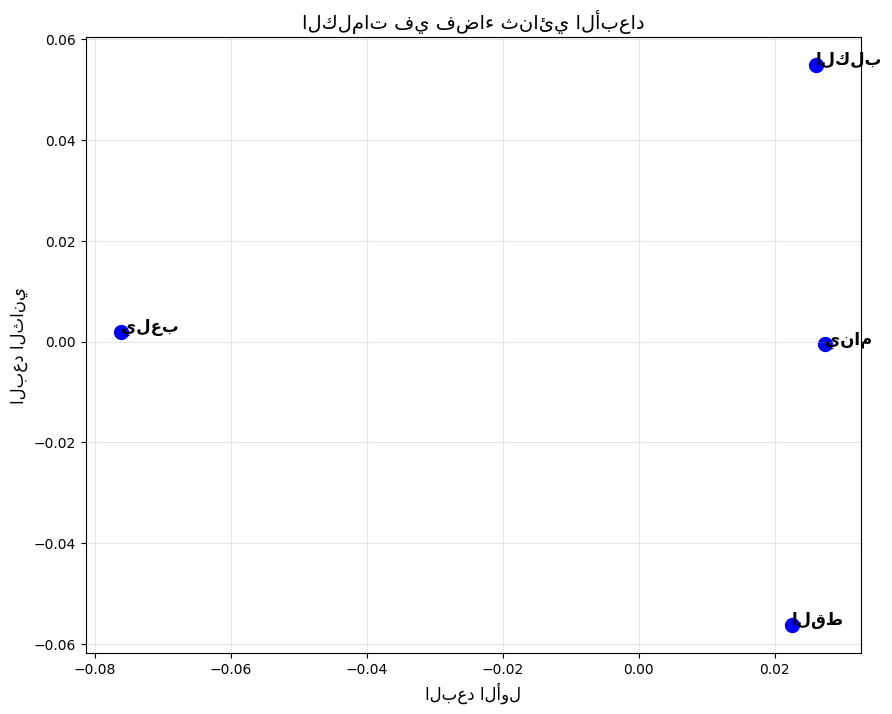


💾 حفظ النموذج:
✅ تم حفظ النموذج في 'word2vec_model.model'

📂 تحميل النموذج المحفوظ:
✅ تم التحميل!

📊 مقارنة التشابه:
   التشابه بين 'يلعب' و 'ينام': -0.09


In [21]:
# ===========================================
# Word Embedding - شرح عملي
# ===========================================

import numpy as np
from gensim.models import Word2Vec
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 1️⃣ بيانات للتدريب (جمل بسيطة)
sentences = [
    ["الكلب", "يلعب", "في", "الحديقة"],
    ["القط", "ينام", "على", "السرير"],
    ["الكلب", "يأكل", "الطعام"],
    ["القط", "يشرب", "الحليب"],
    ["السيارة", "تسير", "بسرعة"],
    ["الدراجة", "بطيئة", "جداً"],
    ["القط", "يلعب", "مع", "الكلب"],
    ["السيارة", "حمراء", "وجميلة"]
]

print("📚 بيانات التدريب:")
for i, sent in enumerate(sentences, 1):
    print(f"   {i}. {' '.join(sent)}")

# 2️⃣ تدريب نموذج Word2Vec
print("\n🔄 جاري تدريب النموذج...")
model = Word2Vec(
    sentences=sentences,
    vector_size=50,      # حجم المتجه
    window=3,            # عدد الكلمات المحيطة
    min_count=1,         # أقل تكرار للكلمة
    workers=4,           # عدد المعالجات
    epochs=100           # عدد مرات التدريب
)

print("✅ تم التدريب!")

# 3️⃣ الحصول على متجهات الكلمات
print("\n📊 متجهات الكلمات (أول 5 أرقام فقط):")
words = ['الكلب', 'القط', 'سيارة', 'يلعب', 'ينام']
for word in words:
    if word in model.wv:
        vector = model.wv[word]
        print(f"   {word}: {vector[:5]}... (طول المتجه: {len(vector)})")

# 4️⃣ إيجاد الكلمات المتشابهة
print("\n🔍 كلمات مشابهة لـ 'كلب':")
similar_words = model.wv.most_similar('الكلب', topn=3)
for word, score in similar_words:
    print(f"   → {word} (تشابه: {score:.2f})")

print("\n🔍 كلمات مشابهة لـ 'يلعب':")
similar_words = model.wv.most_similar('يلعب', topn=3)
for word, score in similar_words:
    print(f"   → {word} (تشابه: {score:.2f})")

# 5️⃣ تشبيه: ملك - رجل + امرأة = ملكة
print("\n🧮 تشبيه رياضي (Word Analogies):")
try:
    result = model.wv.most_similar(positive=['قط'], negative=['كلب'], topn=1)
    print(f"   كلب - قط + ? : {result[0][0]} (توجد مشكلة في البيانات الصغيرة)")
except:
    print("   (يحتاج بيانات أكبر للتشبيهات المعقدة)")

# 6️⃣ رسم بياني للكلمات
print("\n📈 رسم الكلمات في فضاء ثنائي الأبعاد:")

# اختيار كلمات للرسم
words_to_plot = ['الكلب', 'القط', 'يلعب', 'ينام', 'سيارة', 'دراجة']
word_vectors = [model.wv[word] for word in words_to_plot if word in model.wv]
words_plotted = [word for word in words_to_plot if word in model.wv]

# تقليل الأبعاد إلى 2D
pca = PCA(n_components=2)
vectors_2d = pca.fit_transform(word_vectors)

# الرسم
plt.figure(figsize=(10, 8))
plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], c='blue', s=100)

for i, word in enumerate(words_plotted):
    plt.annotate(word, (vectors_2d[i, 0], vectors_2d[i, 1]),
                 fontsize=12, fontweight='bold')

plt.title('الكلمات في فضاء ثنائي الأبعاد', fontsize=14)
plt.xlabel('البعد الأول', fontsize=12)
plt.ylabel('البعد الثاني', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

# 7️⃣ حفظ وتحميل النموذج
print("\n💾 حفظ النموذج:")
model.save("word2vec_model.model")
print("✅ تم حفظ النموذج في 'word2vec_model.model'")

# 8️⃣ تحميل النموذج مرة أخرى
print("\n📂 تحميل النموذج المحفوظ:")
loaded_model = Word2Vec.load("word2vec_model.model")
print("✅ تم التحميل!")

# 9️⃣ مقارنة التشابه بين كلمتين
print("\n📊 مقارنة التشابه:")
pairs = [('كلب', 'قط'), ('كلب', 'سيارة'), ('يلعب', 'ينام'), ('سيارة', 'دراجة')]

for w1, w2 in pairs:
    if w1 in model.wv and w2 in model.wv:
        similarity = model.wv.similarity(w1, w2)
        print(f"   التشابه بين '{w1}' و '{w2}': {similarity:.2f}")



In [22]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# النصوص
docs = [
    "الكلب يلعب في الحديقة",
    "القط ينام على السرير",
    "السيارة تسير بسرعة",
    "الدراجة بطيئة جداً"
]

# تحويل النصوص لأرقام
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(docs)

# تدريب LDA
lda = LatentDirichletAllocation(n_components=2)
lda.fit(X)

# عرض المواضيع
feature_names = vectorizer.get_feature_names_out()
for topic_idx, topic in enumerate(lda.components_):
    top_words = [feature_names[i] for i in topic.argsort()[:-6:-1]]
    print(f"الموضوع {topic_idx}: {' '.join(top_words)}")

الموضوع 0: على السرير القط ينام في
الموضوع 1: السيارة بسرعة تسير بطيئة الدراجة


In [23]:
# ===========================================
# LDA - مثال بسيط مع شرح
# ===========================================

# 1️⃣ تثبيت المكتبات
!pip install scikit-learn

# 2️⃣ استيراد المكتبات
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# 3️⃣ بيانات بسيطة (نصوص عربية)
documents = [
    "الكلب يلعب في الحديقة",      # نص 1
    "القط ينام على السرير",       # نص 2
    "السيارة تسير بسرعة",         # نص 3
    "الدراجة بطيئة جداً",         # نص 4
    "الكلب والقط حيوانات أليفة",  # نص 5
    "السيارة الحمراء جميلة",      # نص 6
]

print("📚 النصوص:")
for i, doc in enumerate(documents, 1):
    print(f"   نص {i}: {doc}")

# 4️⃣ تحويل النصوص إلى أرقام (Bag of Words)
print("\n🔄 تحويل النصوص لأرقام...")
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(documents)

print(f"   شكل المصفوفة: {X.shape}")
print(f"   الكلمات: {vectorizer.get_feature_names_out()}")

# 5️⃣ تدريب نموذج LDA
print("\n🧠 تدريب LDA...")
lda = LatentDirichletAllocation(n_components=2, random_state=42)  # نبحث عن موضوعين
lda.fit(X)

# 6️⃣ عرض النتائج (المواضيع)
print("\n📊 المواضيع المكتشفة:")
print("-"*50)

feature_names = vectorizer.get_feature_names_out()

for topic_idx, topic in enumerate(lda.components_):
    # ترتيب الكلمات حسب الأهمية
    top_words_idx = topic.argsort()[:-6:-1]  # أفضل 5 كلمات
    top_words = [feature_names[i] for i in top_words_idx]
    print(f"\nالموضوع {topic_idx + 1}:")
    print(f"   الكلمات المهمة: {top_words}")
    print(f"   الأوزان: {topic[top_words_idx]}")

# 7️⃣ توقع الموضوع لكل نص
print("\n📌 توزيع المواضيع لكل نص:")
print("-"*50)

topic_distribution = lda.transform(X)

for i, doc in enumerate(documents):
    print(f"\nنص {i+1}: {doc}")
    for j, prob in enumerate(topic_distribution[i]):
        print(f"   احتمال الموضوع {j+1}: {prob:.2f}")

📚 النصوص:
   نص 1: الكلب يلعب في الحديقة
   نص 2: القط ينام على السرير
   نص 3: السيارة تسير بسرعة
   نص 4: الدراجة بطيئة جداً
   نص 5: الكلب والقط حيوانات أليفة
   نص 6: السيارة الحمراء جميلة

🔄 تحويل النصوص لأرقام...
   شكل المصفوفة: (6, 19)
   الكلمات: ['أليفة' 'الحديقة' 'الحمراء' 'الدراجة' 'السرير' 'السيارة' 'القط' 'الكلب'
 'بسرعة' 'بطيئة' 'تسير' 'جدا' 'جميلة' 'حيوانات' 'على' 'في' 'والقط' 'يلعب'
 'ينام']

🧠 تدريب LDA...

📊 المواضيع المكتشفة:
--------------------------------------------------

الموضوع 1:
   الكلمات المهمة: ['السيارة', 'الكلب', 'حيوانات', 'أليفة', 'والقط']
   الأوزان: [1.62302632 1.5570503  1.49579459 1.49579459 1.49579459]

الموضوع 2:
   الكلمات المهمة: ['على', 'القط', 'ينام', 'السرير', 'بطيئة']
   الأوزان: [1.49196391 1.49196391 1.49196391 1.49196391 1.48910429]

📌 توزيع المواضيع لكل نص:
--------------------------------------------------

نص 1: الكلب يلعب في الحديقة
   احتمال الموضوع 1: 0.12
   احتمال الموضوع 2: 0.88

نص 2: القط ينام على السرير
   احتمال الموضوع 1: